# **Classification Course**


---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to classification problems***. We will use **"decision tree" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***. The goal is to practice the knowledge required for each step depending on the level.

# Level 1 (★☆☆)


---

Level 1 builds on the methods introduced in Level 0 and applies them to more practical datasets, with a focus on processing data and model building.

##1.1. Understanding the Data (Part 1)

Let’s begin by exploring the dataset we'll be working with. This step is essential for effective data transformation and model building later on. In this dataset, we will be dealing with data related to the appearance of poisonous mushrooms, such as their colors and patterns.

First, download the `Mushroom_Appearence_Data.csv` from the link below. Hover over the blue text, click to open the page, and click the download button. If you don't see the button, click the ︙ (More Options) icon and select "Download" from the menu.

[Mushroom_Appearence_Data.csv](https://drive.google.com/file/d/19NKE8PgEhgE9b5WZnFgmWkZ-D2DR2NIe/view?usp=drive_link)

After downloading, drag and drop the CSV file into the same location you used in Level 0. (Click and hold the left mouse button on the file, then move it to the desired location). Once uploaded, use the following code to read the CSV file and display it as a DataFrame.

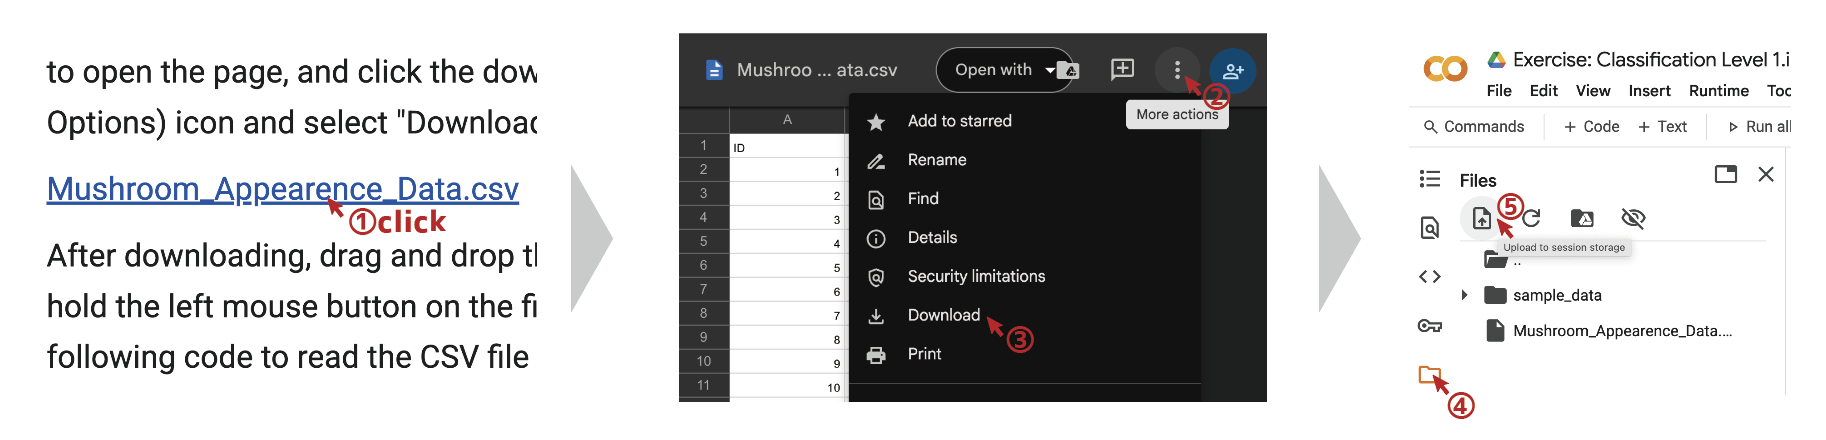

In [ ]:
# Import pandas
import pandas as pd

# Load the csv file
df = pd.read_csv('Mushroom_Appearence_Data.csv')

You are assigning the DataFrame object returned by the `read_csv()` function in pandas to the variable `df`. Furthermore, by using the `len()` function, you can confirm the number of data points.

In [ ]:
# Check the number of rows in the DataFrame
len(df)

8124

The data we are working with is originally from the data publicly available on the UC Irvine Machine Learning Repository (
https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
) and has been processed for learning. The dataset contains almost 8000 records, making it impractical to inspect each data point individually as we did in the previous level.

Let's start by directly examining around ten data points and then proceed to investigate each feature. By using the `head()` method of the DataFrame object, you can display the first several rows of data. By passing the number as an argument, you can specify the number of rows to display. If you do not specify the number of rows, the first five rows will be displayed by default. If you want to display a specific number of rows from the end, you can use the `tail()` method.

In [ ]:
# Display the specified number of rows (10) from the beginning
df.head(10)

,ID,bruises,cap_color,poison
0,1,Y,n,Y
1,2,Y,y,N
2,3,Y,w,N
3,4,NaN,w,Y
4,5,NaN,g,N
5,6,NaN,y,N
6,7,Y,w,N
7,8,Y,w,N
8,9,Y,w,Y
9,10,Y,y,N


In the displayed results, we can see the features `bruises` and `cap_color`. Based on this categorical data, we will build a model to predict the presence of `poison`, the target label. The `ID` is the identification number of the mushroom and is not a feature. Both `bruises` and `poison` are represented by the initial letters of Yes or No. `cap_color` has various colors, abbreviated to a single lowercase alphabet. We will check the meanings of the symbols later.

One thing to note is that in the column `bruises`, we see entries labeled as `NaN`. **`NaN` stands for "Not a Number"** and is a special value called a missing value. When there is a missing value in the loaded file, pandas fills those places with the value `NaN`. If you open the uploaded CSV file by double-clicking, you will see that the `NaN` entries appear as blanks.


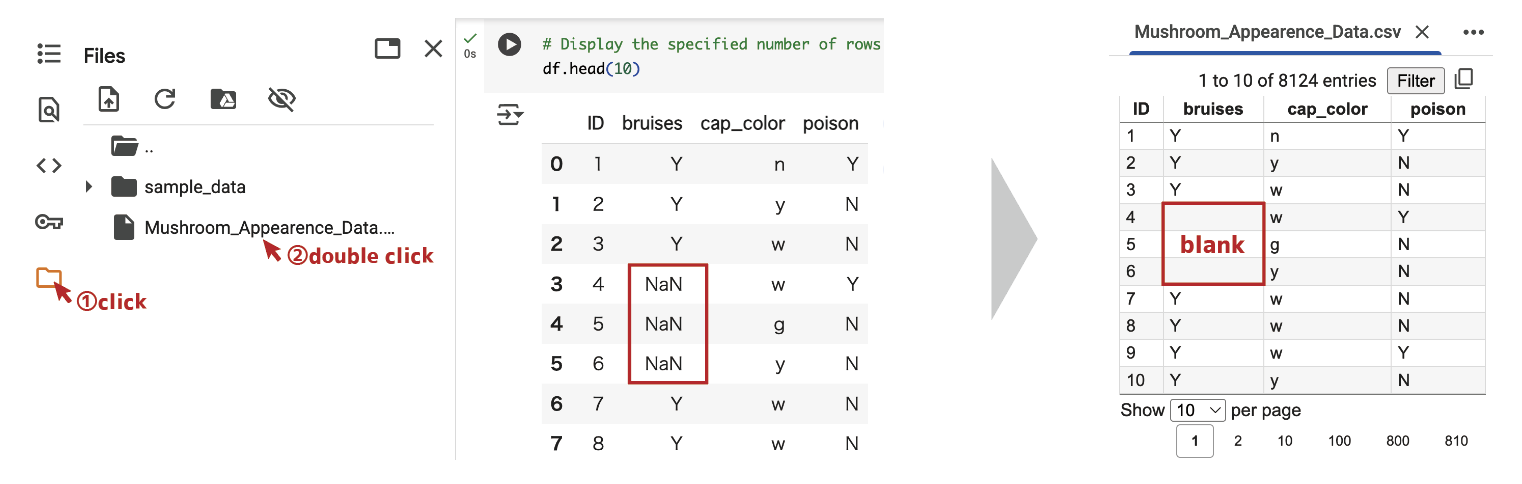

Let's start by looking at the types of cap colors. First, we will extract the `cap_color` column from the `DataFrame` object using the method introduced in Level 0 and assign it as variable `cap_color_se`. We learned in Level 0 that extracting a single column from a `DataFrame` object creates a `Series` object. By calling the `unique()` method on `cap_color_se`, which is a `Series` object, we can determine the different types present in that column. (See method 1 below)

 It is worth noting that the column extraction and the `unique()` method can be written consecutively without intermediate variable assignments. The code sequentially extracts the column and checks the types from the beginning, and apart from variable assignment, the actual process remains the same. (See method 2 below)

In programming, it's common to write code in a chained manner, which can sometimes make it difficult to understand what’s actually happening. By mentally stepping through the process from the beginning, the code becomes much easier to understand.

In [ ]:
# Check colors (method 1)
cap_color_se = df['cap_color']
cap_color_unique = cap_color_se.unique()
print(cap_color_unique)

# Check colors (method 2)
print(df['cap_color'].unique())

Now you should see 10 different colors. The abbreviations for each color are as shown in the table below.

| Abbreviation | Color | |
|-----|------|----|
| n | Brown |<font color = "brown">●</font>
| y | Yellow |<font color = "yellow">●</font>
| w | White |<font color = "white">●</font>
| g | Grey |<font color ="grey">●</font>
| p | Pink |<font color ="pink">●</font>
| b | Buff |<font color ="#cfab72">●</font>
| u | Purple|<font color = "purple">● </font>
| c | Cinnamon |<font color = "#b6710d">● </font>
| r | Green |<font color = "green">●</font>
| e | Red |  <font color = "red">●</font>

Next, let's investigate the **missing values**. Checking for missing values is essential in real-world data analysis. A **missing value** refers to a data point that, for some reason, was not recorded and therefore does not exist. This corresponds to the `NaN` we confirmed earlier. Since analysis cannot proceed properly when missing values are present, the first step when working with a new dataset is to check for them. If missing values are found, we need to handle them appropriately. Although we’ve already seen that the `bruises` column has missing values shown as `NaN`, we don’t yet know whether other columns also have them or how many there are in total.

To investigate this, you can use the `isnull()` method of the `DataFrame`, which returns another `DataFrame` where each row is either `True` (if the value is missing) or `False` (if the value is present).


In [ ]:
# Check for missing values
df_isnull = df.isnull()
df_isnull.head(10)

Furthermore, when using the `sum()` method, `True` is treated as 1 and `False` as 0. It returns a Series object that sums the number of `Trues`, which represents missing values, in each column. This allows you to check the counts of missing values in each column. The original column names (`ID`, `bruises`, `cap_color`, `poison`) serve as the index for this Series object.

In [ ]:
# Check the number of missing values in each column
df_isnull.sum()

Missing values exist only in the `bruises` column, and there are 1624 missing values.

To explain the process step by step, we first stored the DataFrame returned by the `isnull()` method in a variable, and then applied the `sum()` method. However, these methods can also be chained together in a single line. Going forward, we’ll use the more concise version when checking for missing values.

In [ ]:
df.isnull().sum()

## 1.2. Processing Data (Part 1)

Next, we will proceed with data preprocessing. In this case, since the features are qualitative data, dummy variables are necessary. Additionally, we need to handle the previously unseen missing values.

There are two methods for handling missing values: deletion and replacing. In Level 1, we will focus on deleting missing values, and in Level 2, we will cover replacing.

**[Handling Missing Values]**

- Deleting Missing Values (Level 1★☆☆)
    - Deleting columns with missing values
    - Deleting rows with missing values
- Replacing Missing Values (Level 2★★☆)

In our dataset, there were missing values only in the `bruises` column. Therefore, let's delete the `bruises` column before training the model. Even though we say delete, no special processing is required. We will just use the `cap_color` as a dummy variable for training data without using the `bruises` column. The process of creating dummy variables remains the same as before.

In [ ]:
df_dummy = pd.get_dummies(df['cap_color'], drop_first = True, dtype = int)
df_dummy.head()

The dummy variable encoding in Level 0 returned only one column because the `bruises` column had only 2 values (Yes or No). This time there are 10 categories, resulting in 9 columns. Each column is converted to False (0) or True (1), which increases the number of columns. While it is possible to assign color types to 0, 1, 2...9, machine learning models may also learn the numerical order as a feature. Since the color types in this case are symbols without an inherent order, they are divided into each column and represented as 0 or 1.

In Level 1, we will also build a classification model using a decision tree just like in Level 0. The processes for model building and evaluation will be very similar to the previous level. In Level 0, we trained the model on all the data and evaluated the model's predictive accuracy on the same data. However, this method does not allow us to evaluate if the model can predict unknown data. The primary goal of machine learning is to **build a model and then use it to make predictions on unknown data**. One way to evaluate the predictive accuracy on unknown data is through a technique called **holdout method**.

The holdout method involves splitting the data into two sets: one for training (**training data**) and the other for evaluation (**test data**). We train the model using only the training data and then evaluate the predictive accuracy on the test data, which was not used in model training. This approach is similar to how one would approach studying for an exam using past papers. Instead of studying all the past papers and answers at once, some past papers are kept for later use as a test to check the understanding after studying.

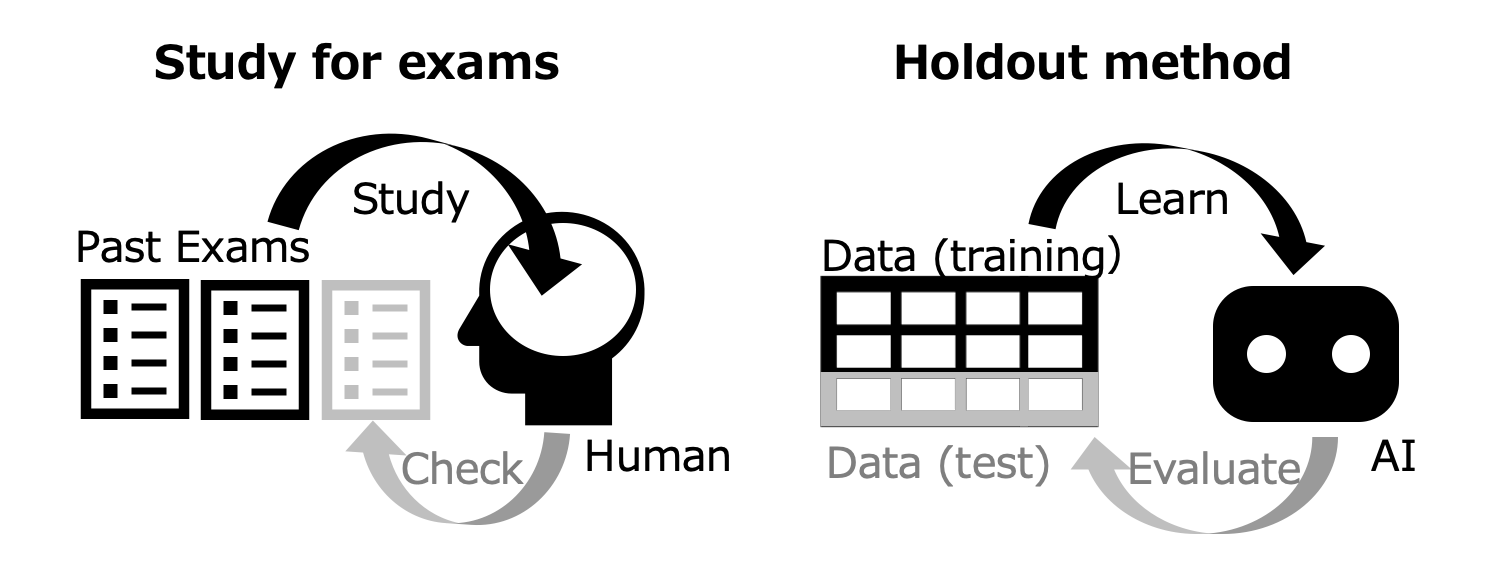

>**\[Validation Data]**
>
>We introduced the holdout method as a way to divide data for training and evaluation purposes. However, in practical scenarios, it is common to further divide the training data into **training data** and **validation data**. In model building, the hyperparameters set in the model beforehand (such as random numbers, tree depth, and impurity calculation formula in the case of decision trees) also contribute to prediction accuracy. Adjusting various hyperparameters to improve prediction accuracy on test data alone may lead to constructing a model optimized only for the current test data. To validate the selection of hyperparameters, we create **validation data**. "You can think of textbook problems as training data, mock exams as validation data, and real exams as test data. Simply memorizing textbook problems or aligning study with the trends of mock exams does not necessarily guarantee good results in the actual exam. Therefore, to achieve a more reliable accuracy evaluation of the model, the holdout method, where data is divided into three parts, is adopted. However, since this is an introductory course, we’ll build and evaluate the model using only training and test data. We won’t adjust the model’s hyperparameters to optimize performance on the test data—instead, we’ll use the default settings.

The holdout method can be easily implemented using the `train_test_split()` function in `scikit-learn`. By passing the features and target variables as arguments to the `train_test_split()` function, a list of `[features (training data), features (test data), target variable (training data), target variable (test data)]` is returned. While it is possible to assign this list directly to a variable, using unpacking to separate each data into variables is more convenient. Unpacking involves preparing variable names for each element of the list, and upon assignment, each element is separated and assigned to each variable. The following is a simple example:

>**\[Example of Unpacking Assignment for a List]**
>
>```python
list_data = [1, 2, 3, 4]
a, b, c, d = list_data
```
>`a` will be assigned `1`, `b` will be assigned `2`, `c` will be assigned `3`, and `d` will be assigned `4`.

Now, let's import the `train_test_split()` function from `model_selection` in `scikit-learn`, and divide the dummy variables of features and labels into training data and test data.

>**[train_test_split]**
>>
```Python
feature_train, feature_test, label_train, label_test
= train_test_split(feature_data_frame, label_series, test_size = ratio_of_test_data (specify between 0 and 1))
```
>`test_size` is optional. If not specified, default is `test_size = 0.25`.

Let's build a decision tree model using the training data split. The process of building the model is the same as at level 0.

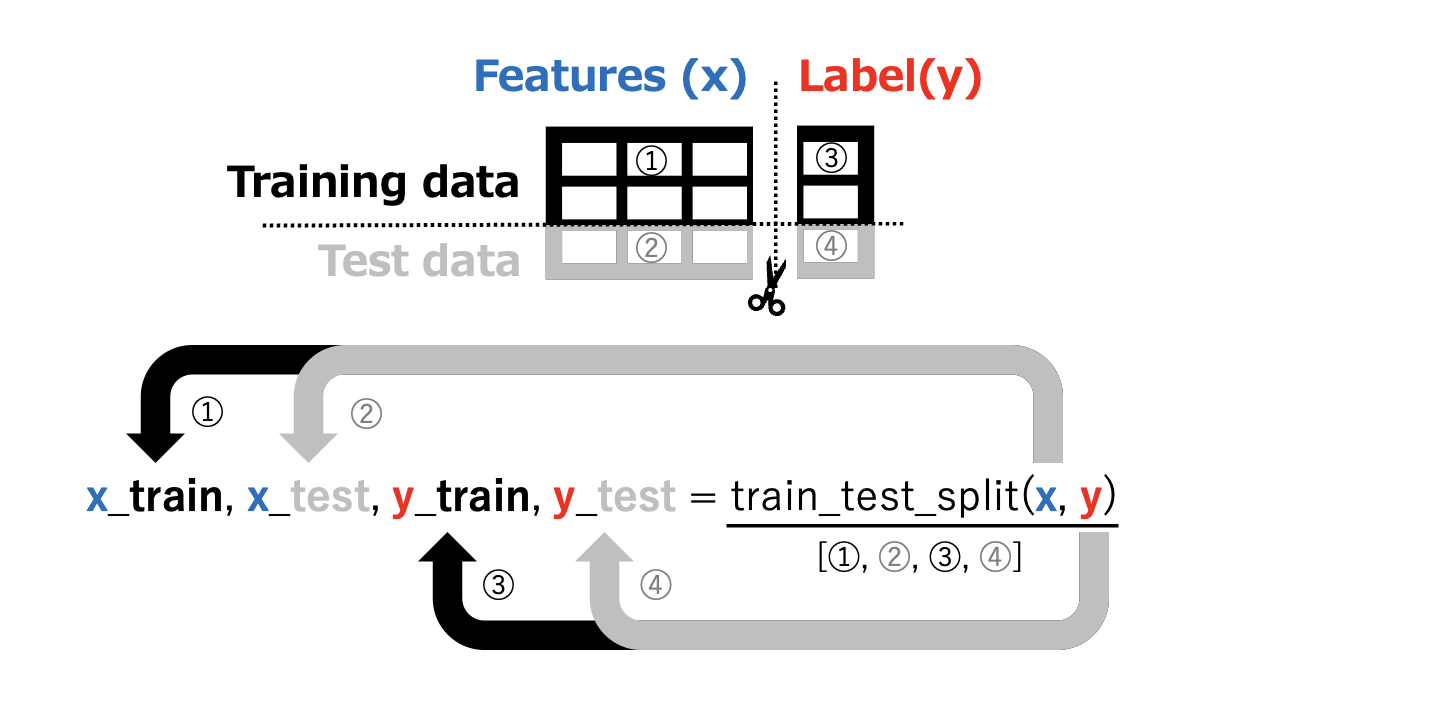

In [ ]:
# Importing train_test_split function from scikit-learn's model_selection
from sklearn.model_selection import train_test_split

x = df_dummy
y = df['poison']

x_train, x_test, y_train, y_test = train_test_split(x, y)

print('Number of data before splitting:', len(df))
print('Number of training data:', len(x_train))
print('Number of test data:', len(x_test))
print('Ratio of test data:', len(x_test)/len(df))

By default, 25% of the data is set as the test data. However, you can change it to 30% by specifying the argument `test_size=0.3` in the train_test_split function. When you put a comma inside the parentheses of the print function and pass multiple values as arguments, they will be displayed in the same row with spaces to separate them.

## 1.3. Model Building and Evaluation (Part 1)

In [ ]:
# Building the model
# (import the library -> instantiate the model -> train the model)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

The model training is now complete. Let's evaluate the model using the `score()` method that was introduced in Level 0.
Previously, we evaluated the model on the same data used for training, but this time, let's calculate the accuracy on the training data used for learning and also on the test data not included in the training. The prediction error on the training data is called training error, and the prediction error on the test data is called **generalization error**. The values will be rounded to 3 decimal places using the `round()` function. The `round()` function is a built-in Python function used for rounding numbers. It takes two arguments: the number to round and the number of decimal places to round to.

In [ ]:
train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)
print('Training Data Accuracy:', round(train_score, 3))
print('Test Data Accuracy:', round(test_score, 3))

As a result, we can see that the training error and the generalization error are roughly the same, indicating that the model is capable of handling unknown data. The accuracy rate is 60%. In this case, since it is a binary classification of poisonous or non-poisonous mushrooms, randomly guessing would yield an accuracy rate of around 50%. The fact that the model's accuracy is higher than this random baseline shows that it can make predictions better than guessing randomly.

It is also important to consider the proportion of poisonous mushrooms when evaluating the accuracy. For instance, if only 10% of the mushrooms are poisonous, simply classifying all mushrooms as non-poisonous would already result in 90% accuracy.

Let's check the number of poisonous mushrooms in this case. When you want to know not only the types but also the numbers, specify the column of the DataFrame and use the `value_counts()` method. Although in the example below, the column specification and method call are written on different lines, you can also combine them into a single line like this: `df['poison'].value_counts()`.

In [ ]:
se_poison = df['poison']
se_poison.value_counts()

In this case, since there were almost equal numbers of poisonous mushrooms (Y) and non-poisonous mushrooms (N), there was no issue. However, if there is imbalance in the data, it is necessary to revise evaluation methods and model training techniques. Therefore, it is a good practice to check the proportion of the correct labels (presence of poisonous mushrooms) during the initial stage of understanding the data.

## 1.4. Understanding the Data (Part 2)

In the previous model training where the column with missing values (`bruises`) was removed, the prediction accuracy was around 60%. While a 60% accuracy rate may be considered passing in some exams, we aim for a higher accuracy this time. In the previous approach, we removed all columns with missing values. However, as only 1,000 records have missing values, we can still use the remaining $\frac{7}{8}$ of the entire data. If `bruises` are indeed useful for predicting poisonous mushrooms, incorporating them into the model training can lead to higher accuracy.

Now, let's examine how the number of poisonous mushrooms varies depending on the presence or absence of bruises. We can count the numbers using the same method as before with the `value_counts()` method. However, to consider two columns as criteria, we will apply the `value_counts()` method to a DataFrame object that extracts the bruises and poison columns. This will calculate the frequency of combinations of bruises and poison presence, excluding missing values from the calculation.

In [ ]:
se_b_p_counts = df[['bruises','poison']].value_counts()
se_b_p_counts

From the displayed results, we can see four types of counts for `bruises` with Yes/No and `poison` with Yes/No. The Series object when checking the number of poisons is slightly different from the displayed results. This is because we called the `value_counts()` method on a DataFrame object with two columns, resulting in a Series object with a two-level index. Such multiple indices are called **hierarchical indices**. By checking with the `index` attribute, you can confirm the two-column indices and their names.

In [ ]:
se_b_p_counts.index

The numerical values returned by the `value_counts()` method are sorted in descending order. To rearrange the table in the order of the index, you can use the `sort_index()` method. In the case of a two-level index, the resulting Series object will first be sorted based on the leftmost first layer, and then within that based on the right second layer.

In [ ]:
# Sort the index of a Series object
se_b_p_counts = se_b_p_counts.sort_index()
se_b_p_counts

By specifying the first layer of the index using square brackets `[ ]` in a two-level index, the display result of the Series object will be the same as before. In the following code cell, we are selecting `N` for bruises and displaying the number of poisonous mushrooms (Y) and non-poisonous mushrooms (N).

In [ ]:
se_b_p_counts['N']

Upon further checking the index attribute, you should see that it is a single-column index.

In [ ]:
se_b_p_counts['N'].index

Since we have a small number of numerical values, you can already see the characteristics of bruises and poison counts from the table.

However, visualizing them with graphs makes it easier to see them. Let's use the matplotlib library, a convenient tool for plotting graphs. The pyplot module of matplotlib contains many functions that can be used for graphing. pyplot is commonly imported with the name `plt`.

In [ ]:
import matplotlib.pyplot as plt

Here, we will compare the number of poisonous and non-poisonous mushrooms when bruise is `N` (no bruises) and when bruise is `Y` (bruises). A bar graph is suitable for this type of comparison. To create a bar graph, we will use the `bar()` function in `plt`. Input the index as the first argument and the the height of the bar as the second argument.

Let's plot a **stacked bar graph**. To visualize two bar graphs stacked vertically, we will use the `bottom` argument for the second graph we want to plot.

In [ ]:
# bar graph for mushrooms with no bruises
plt.bar(se_b_p_counts['N'].index, se_b_p_counts['N'])
# bar graph for mushrooms with bruises
plt.bar(se_b_p_counts['Y'].index, se_b_p_counts['Y'], bottom=se_b_p_counts['N'])

The <font color = "#1F77B4">blue bar graph at the bottom</font> shows the number of poisonous (Y) and non-poisonous (N) mushrooms when there are no bruises, while the <font color = "#FF7F0E">orange bar graph at the top</font> shows the same for mushrooms with bruises. You should see that mushrooms without bruises have a higher number of poisonous ones, and mushrooms with bruises have a higher number of non-poisonous ones, indicating a different trend. Therefore, the `bruises` column is considered a useful feature for predicting whether a mushroom is poisonous or not.

Next, let's build a model using the data excluding missing values of bruises.

## 1.5. Processing Data (Part 2)

To delete data with missing values, you can use the `dropna()` method of the DataFrame object. By using the `dropna()` method, rows containing any missing values are removed, and a new DataFrame object without missing values is returned, which is then assigned to a new variable called `df_drop`.

In [ ]:
# Drop rows with missing values
df_drop = df.dropna()

# Check the number of missing values
df_drop.isnull().sum()

Keep in mind that missing values are not removed from the original DataFrame object itself. You can confirm the missing values by using the `isnull()` method on the original variable `df`.

In [ ]:
# Check for missing values in the original data frame
df.isnull().sum()

In [ ]:
print('Number of data before deletion', len(df))
print('Number of data after deletion', len(df_drop))

About a thousand rows with missing values have been deleted, and you can see that there are no missing values in the `df_drop` dataset. Now, let's convert the `cap_color` and `bruises` columns in `df_drop` into dummy variables as we did before. Additionally, let's split the data into training and test data.

In [ ]:
x = pd.get_dummies(df_drop[['cap_color', 'bruises']], drop_first= True)
y = df_drop['poison']

x_train, x_test, y_train, y_test = train_test_split(x, y)

## 1.6. Model Building and Evaluation (Part 2)

Now, let's train the model with the training data and take a look at the accuracy with the test data.

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
test_score = model.score(x_test, y_test)
round(test_score,3)

We have achieved an accuracy rate of 80%. By utilizing more data, the accuracy rate has improved. However, it is not certain whether this improvement will always happen until we try it out. Additionally, a model trained without removing columns with missing values can handle unknown data with missing values in the future, but a model trained by removing rows with missing values cannot handle unknown data including missing values. Whether to remove missing values or not depends on whether the data with missing values is crucial in solving the analytical task. If missing values can be appropriately replaced with values, the model can handle unknown data with missing values.

In Level 2, we will learn about how to fill in missing values rather than deleting them.

>**[What is a good accuracy rate?]**
>What percentage is considered good for the accuracy rate? In this exercise, as you progress through all levels, the goal is to achieve an accuracy rate close to 100%. However, in practical data scenarios, raising the accuracy rate requires various efforts such as hyperparameter tuning, considering model selection other than decision trees, feature engineering, and repeating various improvements, will require time and cost. In business applications, if you quantitatively evaluate how much cost reduction or profit increase using a prediction from a model can lead to, the sufficient accuracy may not necessarily be 100% and a lower percentage could be enough. Additionally, one approach is to build a model first, operate it in practice, accumulate data on errors, and use it for improving the model.

## 1.7. Practice Problems

**Q1-1**. Download the `Classification_Practice.csv` from the link below, upload the file, and read it as a pandas DataFrame. Then, display the first 5 rows to check the data.

[Classification_Practice.csv](https://drive.google.com/file/d/1jiozgbJXrdWIpVvQSOSlAB8a59gYjI_x/view?usp=drive_link)

**Q1-2**. Using the DataFrame from Q1-1, check the number of missing values in each column.

**Q1-3**. How many types of data are present in the second column (column2)?

**Q1-4**. Create a new DataFrame by removing the rows with missing values from the DataFrame in Q1-3.